# 06 Holdout Validation

Evaluate the final MMM on the 26-week test period that was held out from model development.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pymc_marketing.mmm.multidimensional import MMM

RANDOM_SEED = 20260801

MODEL_PATH = Path("../artifacts/mmm_regularized.nc")

train_df = pd.read_csv(
    "../data/scenario_a/scenario_a_train.csv",
    parse_dates=["date_week"],
)

test_df = pd.read_csv(
    "../data/scenario_a/scenario_a_test.csv",
    parse_dates=["date_week"],
)

channel_columns = [
    "tv_spend",
    "google_search_spend",
    "tiktok_spend",
]

control_columns = [
    "promotion",
    "time_index",
]

X_test = test_df[
    [
        "date_week",
        *channel_columns,
        *control_columns,
    ]
].copy()

y_test = test_df["revenue"].to_numpy()

mmm_regularized = MMM.load(MODEL_PATH)

print(f"Training weeks: {len(train_df)}")
print(f"Holdout weeks: {len(test_df)}")

Training weeks: 130
Holdout weeks: 26


In [5]:
posterior_predictive = mmm_regularized.sample_posterior_predictive(
    X=X_test,
    extend_idata=False,
    combined=True,
    include_last_observations=True,
    random_seed=RANDOM_SEED,
)

ppc = posterior_predictive["y"]

target_scale = np.max(
    np.abs(train_df["revenue"].to_numpy())
)

pred_mean = (
    ppc.mean(dim="sample").values
    * target_scale
)

pred_interval = ppc.quantile(
    [0.03, 0.97],
    dim="sample",
)

pred_lower = (
    pred_interval.isel(quantile=0).values
    * target_scale
)

pred_upper = (
    pred_interval.isel(quantile=1).values
    * target_scale
)

Sampling: [y]


Output()

In [6]:
rmse = np.sqrt(
    np.mean((y_test - pred_mean) ** 2)
)

mae = np.mean(
    np.abs(y_test - pred_mean)
)

coverage_94 = np.mean(
    (y_test >= pred_lower)
    & (y_test <= pred_upper)
)

print(f"Holdout RMSE: {rmse:.2f}")
print(f"Holdout MAE: {mae:.2f}")
print(f"94% interval coverage: {coverage_94:.1%}")

Holdout RMSE: 32.04
Holdout MAE: 24.84
94% interval coverage: 100.0%


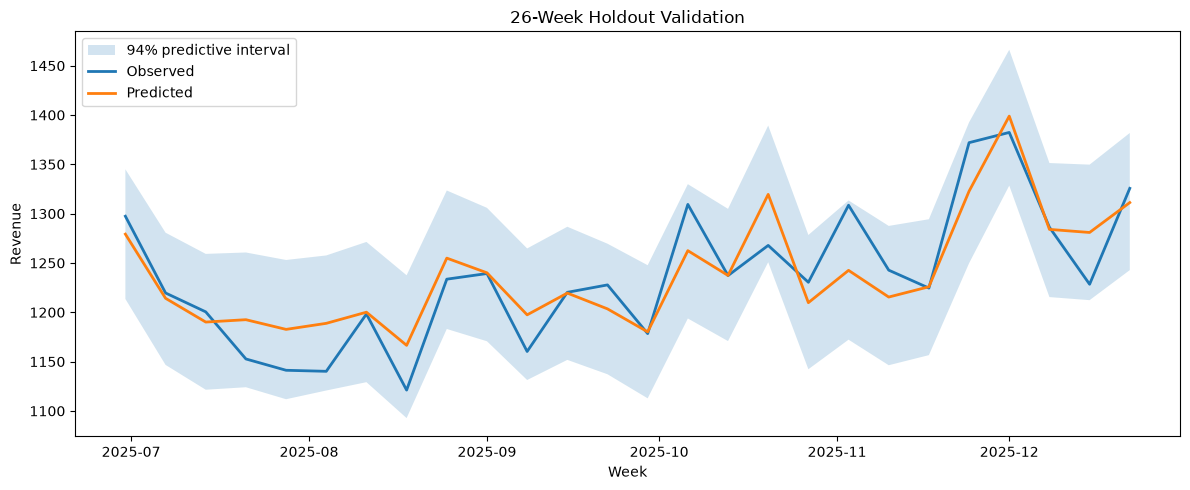

In [7]:
plt.figure(figsize=(12, 5))

plt.fill_between(
    test_df["date_week"],
    pred_lower,
    pred_upper,
    alpha=0.2,
    label="94% predictive interval",
)

plt.plot(
    test_df["date_week"],
    y_test,
    label="Observed",
    linewidth=2,
)

plt.plot(
    test_df["date_week"],
    pred_mean,
    label="Predicted",
    linewidth=2,
)

plt.title("26-Week Holdout Validation")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()